# 05 — OCR Robustness Under Document Degradation

**Research question:** Which degradation types hurt OCR most, and when does preprocessing help?

This notebook is a small controlled research experiment. Write down your prediction before running it: which curve will rise fastest?

## 1. Setup and controlled variables

We hold the page, Tesseract configuration, text normalization, and random seed fixed. The independent variables are degradation type, severity, and preprocessing method. CER is the dependent variable.

In [1]:
from pathlib import Path
import csv
import re
import shutil
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pytesseract

HERE = Path.cwd()
if not (HERE / 'data').exists():
    HERE = HERE / '05_noisy_ocr_experiment'
DATA, OUTPUT = HERE / 'data', HERE / 'output'
DEGRADED = OUTPUT / 'degraded'
DEGRADED.mkdir(parents=True, exist_ok=True)
image = cv2.imread(str(DATA / 'imageTextN.png'))
reference = (DATA / 'ground_truth.txt').read_text(encoding='utf-8')
RANDOM_SEED = 42
print('image shape:', image.shape, 'reference characters:', len(reference))
print('Tesseract found:', shutil.which('tesseract') is not None)

image shape: (257, 556, 3) reference characters: 1069
Tesseract found: True


## 2. Define degradation operators

Each operator accepts a normalized severity from 0 to 1. Synthetic corruption provides exact control but is only an approximation of blur, staining, fading, skew, and damage in real archives.

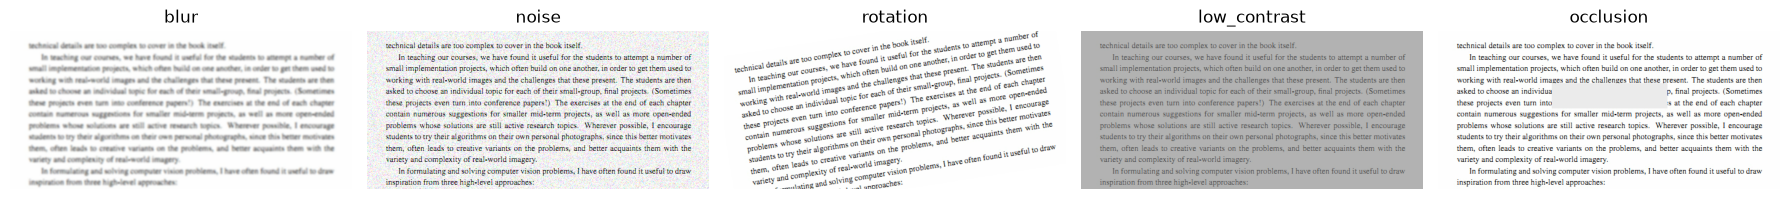

In [2]:
def rotate_white(source, angle):
    height, width = source.shape[:2]
    matrix = cv2.getRotationMatrix2D((width / 2, height / 2), angle, 1.0)
    background = (255, 255, 255) if source.ndim == 3 else 255
    return cv2.warpAffine(source, matrix, (width, height), flags=cv2.INTER_CUBIC,
                          borderMode=cv2.BORDER_CONSTANT, borderValue=background)

def degrade(source, kind, severity, seed=42):
    severity = float(np.clip(severity, 0, 1))
    rng = np.random.default_rng(seed)
    if kind == 'blur':
        kernel = 1 + 2 * max(1, round(severity * 4))
        return cv2.GaussianBlur(source, (kernel, kernel), 0)
    if kind == 'noise':
        noise = rng.normal(0, 45 * severity, source.shape)
        return np.clip(source.astype(np.float32) + noise, 0, 255).astype(np.uint8)
    if kind == 'rotation':
        return rotate_white(source, 12 * severity)
    if kind == 'low_contrast':
        return np.clip(128 + (source.astype(np.float32) - 128) * (1 - 0.8 * severity),
                       0, 255).astype(np.uint8)
    if kind == 'occlusion':
        result = source.copy(); height, width = result.shape[:2]
        box_width = max(1, int(width * 0.45 * severity))
        cv2.rectangle(result, (width // 3, height // 3),
                      (min(width - 1, width // 3 + box_width), height // 3 + 40),
                      (235, 235, 235), -1)
        return result
    raise ValueError(f'Unknown degradation: {kind}')

KINDS = ['blur', 'noise', 'rotation', 'low_contrast', 'occlusion']
fig, axes = plt.subplots(1, len(KINDS), figsize=(18, 4))
for axis, kind in zip(axes, KINDS):
    damaged = degrade(image, kind, 0.75, RANDOM_SEED)
    axis.imshow(cv2.cvtColor(damaged, cv2.COLOR_BGR2RGB)); axis.set_title(kind); axis.axis('off')
plt.tight_layout();

## 3. Define a fixed preprocessing pipeline

This is an ablation: raw and preprocessed inputs use the same OCR engine. Otsu binarization targets contrast/background variation; deskewing targets rotation. It cannot reconstruct information removed by blur or occlusion.

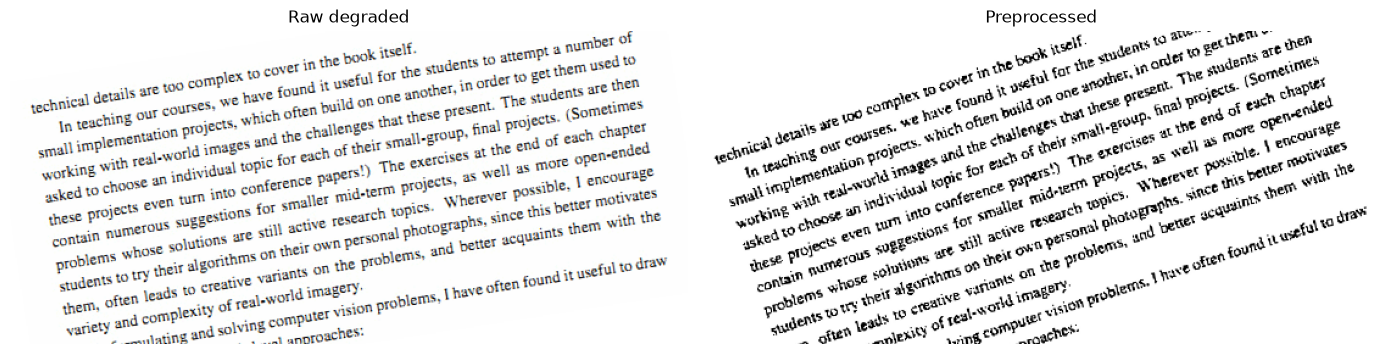

In [3]:
def preprocess(source):
    gray = cv2.cvtColor(source, cv2.COLOR_BGR2GRAY) if source.ndim == 3 else source
    smooth = cv2.bilateralFilter(gray, 7, 35, 35)
    binary = cv2.threshold(smooth, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]
    points = np.column_stack(np.where(binary < 128))
    if len(points) < 20:
        return binary
    angle = cv2.minAreaRect(points[:, ::-1].astype(np.float32))[-1]
    angle = -(90 + angle) if angle < -45 else -angle
    return rotate_white(binary, angle)

example = degrade(image, 'rotation', 0.75, RANDOM_SEED)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(cv2.cvtColor(example, cv2.COLOR_BGR2RGB)); axes[0].set_title('Raw degraded')
axes[1].imshow(preprocess(example), cmap='gray'); axes[1].set_title('Preprocessed')
for axis in axes: axis.axis('off')
plt.tight_layout();

## 4. CER implementation

The memory-efficient dynamic program calculates Levenshtein distance one row at a time. We lowercase and collapse whitespace before evaluation; punctuation remains meaningful.

In [4]:
def normalize(text):
    return re.sub(r'\s+', ' ', text.strip().lower())

def levenshtein(reference_tokens, hypothesis_tokens):
    previous = list(range(len(hypothesis_tokens) + 1))
    for i, reference_token in enumerate(reference_tokens, 1):
        current = [i]
        for j, hypothesis_token in enumerate(hypothesis_tokens, 1):
            current.append(min(current[-1] + 1, previous[j] + 1,
                               previous[j - 1] + (reference_token != hypothesis_token)))
        previous = current
    return previous[-1]

def cer(reference_text, hypothesis_text):
    ref, hyp = list(normalize(reference_text)), list(normalize(hypothesis_text))
    return levenshtein(ref, hyp) / len(ref) if ref else float(bool(hyp))

assert abs(cer('kitten', 'sitting') - 0.5) < 1e-9

## 5. Run the experiment

We first record a clean baseline, then four nonzero severity levels for each degradation. Saving damaged images and recognized text makes unexpected metrics inspectable rather than mysterious.

In [5]:
if shutil.which('tesseract') is None:
    raise RuntimeError('Install Tesseract first: brew install tesseract')

def recognize(candidate):
    return pytesseract.image_to_string(candidate, config='--psm 6').strip()

rows = []
for method, candidate in [('raw', image), ('preprocessed', preprocess(image))]:
    hypothesis = recognize(candidate)
    rows.append({'degradation': 'clean', 'severity': 0.0, 'method': method,
                 'cer': cer(reference, hypothesis), 'ocr_text': hypothesis})

for kind in KINDS:
    for severity in [0.25, 0.50, 0.75, 1.00]:
        damaged = degrade(image, kind, severity, RANDOM_SEED)
        cv2.imwrite(str(DEGRADED / f'{kind}_{severity:.2f}.png'), damaged)
        for method, candidate in [('raw', damaged), ('preprocessed', preprocess(damaged))]:
            hypothesis = recognize(candidate)
            rows.append({'degradation': kind, 'severity': severity, 'method': method,
                         'cer': cer(reference, hypothesis), 'ocr_text': hypothesis})
        print(f'finished {kind:13} severity={severity:.2f}')

with (OUTPUT / 'results.csv').open('w', newline='', encoding='utf-8') as handle:
    writer = csv.DictWriter(handle, fieldnames=rows[0].keys())
    writer.writeheader(); writer.writerows(rows)
print('Measurements:', len(rows))

finished blur          severity=0.25
finished blur          severity=0.50
finished blur          severity=0.75
finished blur          severity=1.00
finished noise         severity=0.25
finished noise         severity=0.50
finished noise         severity=0.75
finished noise         severity=1.00
finished rotation      severity=0.25
finished rotation      severity=0.50
finished rotation      severity=0.75
finished rotation      severity=1.00
finished low_contrast  severity=0.25
finished low_contrast  severity=0.50
finished low_contrast  severity=0.75
finished low_contrast  severity=1.00
finished occlusion     severity=0.25
finished occlusion     severity=0.50
finished occlusion     severity=0.75
finished occlusion     severity=1.00
Measurements: 42


## 6. Plot and interpret

Do not report only the smallest number. Look for slopes, thresholds, and interactions: preprocessing may help one degradation while hurting another.

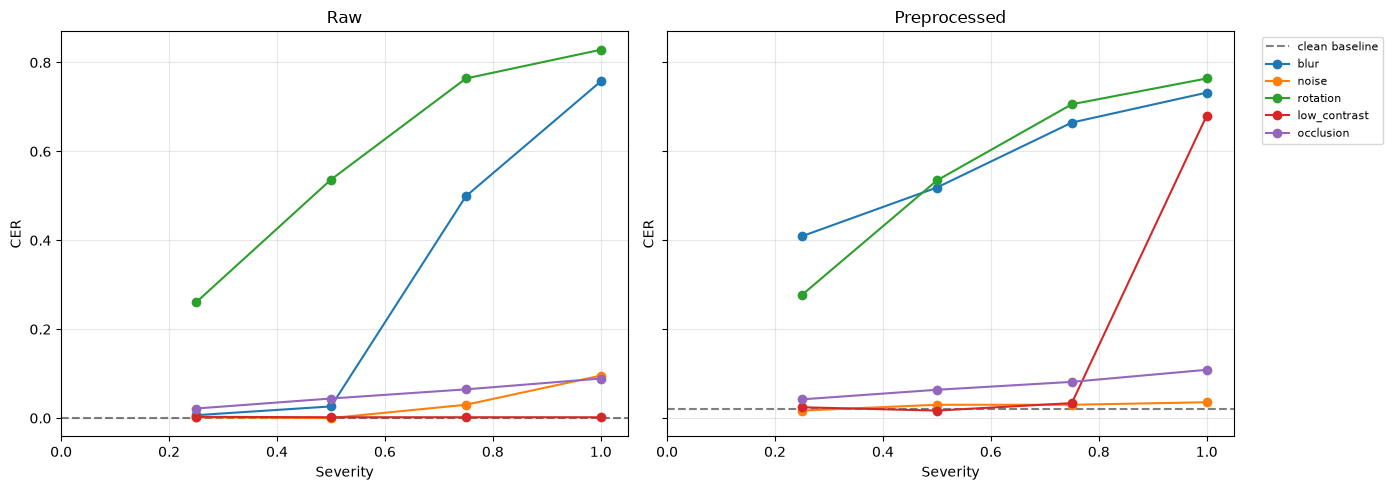

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for axis, method in zip(axes, ['raw', 'preprocessed']):
    baseline = next(row['cer'] for row in rows if row['degradation'] == 'clean' and row['method'] == method)
    axis.axhline(baseline, color='black', linestyle='--', alpha=.5, label='clean baseline')
    for kind in KINDS:
        subset = [row for row in rows if row['degradation'] == kind and row['method'] == method]
        axis.plot([row['severity'] for row in subset], [row['cer'] for row in subset],
                  marker='o', label=kind)
    axis.set(title=method.title(), xlabel='Severity', ylabel='CER', xlim=(0, 1.05))
    axis.grid(alpha=.3)
axes[1].legend(fontsize=8, bbox_to_anchor=(1.04, 1), loc='upper left')
fig.tight_layout(); fig.savefig(OUTPUT / 'cer_plot.png', dpi=150, bbox_inches='tight');

In [7]:
for kind in KINDS:
    worst = max((row for row in rows if row['degradation'] == kind), key=lambda row: row['cer'])
    print(f"{kind:13} worst CER={worst['cer']:.3f} ({worst['method']}, severity={worst['severity']})")

blur          worst CER=0.757 (raw, severity=1.0)
noise         worst CER=0.096 (raw, severity=1.0)
rotation      worst CER=0.829 (raw, severity=1.0)
low_contrast  worst CER=0.681 (preprocessed, severity=1.0)
occlusion     worst CER=0.109 (preprocessed, severity=1.0)


## Research reflection

Write four sentences: (1) method, (2) main result, (3) likely mechanism, and (4) limitation/next experiment. Do not generalize from this single synthetic page to all historical documents. Repeat on more pages and random seeds before making a robust claim.